In [1]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.optimize import NesterovMomentumOptimizer

In [2]:
import os
os.getcwd()

'/home/gen1u5/Documents/projects/qml/QuantumVentures/src/VQCs'

In [3]:
np.random.seed(499122177);

In [4]:
WIRES = 4
dev = qml.device('default.qubit', wires = WIRES);

In [5]:
def layer_prep(layer_weights):
    assert len(layer_weights) == WIRES;
    for qubit, wt in enumerate(layer_weights):
        qml.Rot(*wt, wires = qubit);

    # Entangling the Qubits
    for i in range(WIRES - 1):
        qml.CNOT([i, i + 1]);
    qml.CNOT([WIRES - 1, 0]);

In [8]:
def prepare_state(x):
    qml.BasisState(x, wires = [x for x in range(WIRES)]);

In [10]:
@qml.qnode(dev)
def ckt(weights, x):
    prepare_state(x);

    for layer_weights in weights:
        layer_prep(layer_weights);

    return qml.expval(qml.PauliZ(0));

In [11]:
def classifier(weights, bias, x):
    return ckt(weights, x) + bias

In [13]:
def sq_loss(labels, pred):
    return np.mean((labels - qml.math.stack(pred)) ** 2);

In [14]:
def cost(weights, bias, X, Y):
    pred = [classifier(weights, bias, x) for x in X];
    return sq_loss(Y, pred);

In [15]:
def acc(labels, pred):
    a = sum(abs(l - p) < 1e-5 for l, p in zip(labels, pred));
    a = a / len(labels);
    return a;

In [16]:
## Preparing the data
dataset = np.loadtxt('parity_train.txt', dtype = 'int')
X = dataset[:, :-1]
Y = dataset[:, -1] * 2 - 1

In [17]:
num_qubits = 4
num_layers = 2
weights = 0.01 * np.random.randn(num_layers, num_qubits, 3, requires_grad = True);
bias = np.array(0.0, requires_grad = True);

In [18]:
print(qml.draw(ckt)(weights, 15))

0: ─╭|Ψ⟩──Rot(-0.01,0.01,0.00)───╭●───────╭X──Rot(0.01,-0.01,0.01)───╭●───────╭X─┤  <Z>
1: ─├|Ψ⟩──Rot(-0.03,0.01,0.00)───╰X─╭●────│───Rot(0.01,-0.00,0.02)───╰X─╭●────│──┤     
2: ─├|Ψ⟩──Rot(-0.01,-0.00,-0.00)────╰X─╭●─│───Rot(-0.01,-0.02,-0.02)────╰X─╭●─│──┤     
3: ─╰|Ψ⟩──Rot(-0.01,-0.00,0.01)────────╰X─╰●──Rot(-0.01,-0.01,0.01)────────╰X─╰●─┤     


In [19]:
opt = NesterovMomentumOptimizer(0.5);
batch_size = 5

In [21]:
wts = weights
bs = bias
costs = []
accuracies = []
for _ in range(100):

    batch_idx = np.random.randint(0, len(X), (batch_size, ));
    X_batch = X[batch_idx]
    Y_batch = Y[batch_idx]

    wts, bs = opt.step(cost, wts, bs, X = X_batch, Y = Y_batch);
    predictions = [np.sign(classifier(wts, bs, x)) for x in X]

    curr_cost = cost(wts, bs, X, Y);
    costs.append(curr_cost)
    ac = acc(Y, predictions);
    accuracies.append(acc)
    print(f"Iter: {_+1:4d} | Cost: {curr_cost:0.7f} | Accuracy: {ac:0.7f}")

Iter:    1 | Cost: 2.9570225 | Accuracy: 0.6000000
Iter:    2 | Cost: 2.8609292 | Accuracy: 0.5000000
Iter:    3 | Cost: 2.1322080 | Accuracy: 0.5000000
Iter:    4 | Cost: 1.7242481 | Accuracy: 0.5000000
Iter:    5 | Cost: 1.2047842 | Accuracy: 0.5000000
Iter:    6 | Cost: 0.9499326 | Accuracy: 0.5000000
Iter:    7 | Cost: 1.0535659 | Accuracy: 0.6000000
Iter:    8 | Cost: 2.3058254 | Accuracy: 0.6000000
Iter:    9 | Cost: 0.2950266 | Accuracy: 1.0000000
Iter:   10 | Cost: 0.1577899 | Accuracy: 1.0000000
Iter:   11 | Cost: 0.0809640 | Accuracy: 1.0000000
Iter:   12 | Cost: 0.0375848 | Accuracy: 1.0000000
Iter:   13 | Cost: 0.0221560 | Accuracy: 1.0000000
Iter:   14 | Cost: 0.0166612 | Accuracy: 1.0000000
Iter:   15 | Cost: 0.0216759 | Accuracy: 1.0000000
Iter:   16 | Cost: 0.0237581 | Accuracy: 1.0000000
Iter:   17 | Cost: 0.0144826 | Accuracy: 1.0000000
Iter:   18 | Cost: 0.0102145 | Accuracy: 1.0000000
Iter:   19 | Cost: 0.0043667 | Accuracy: 1.0000000
Iter:   20 | Cost: 0.0016302 | 

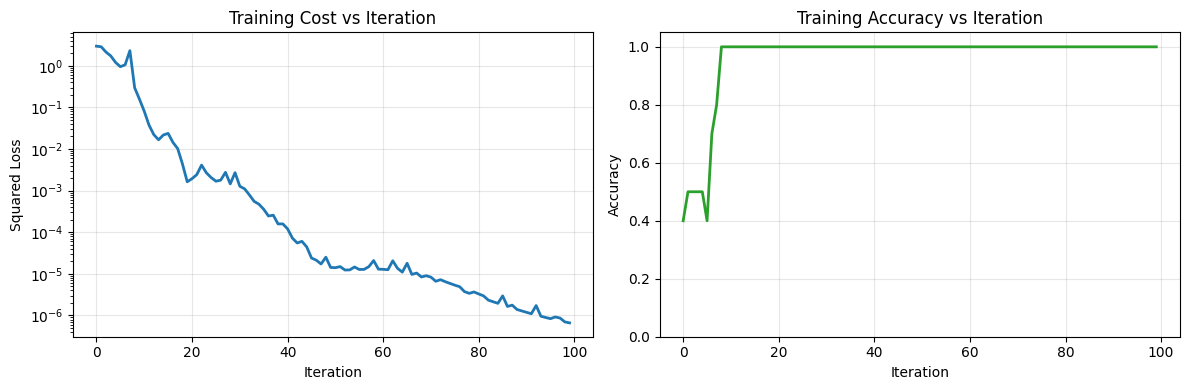

In [22]:
import matplotlib.pyplot as plt

# Convert tensor history to plain floats
cost_vals = [float(c) for c in costs]

# Fix/prepare accuracy history (the existing list contains function objects due append typo)
if len(accuracies) > 0 and not callable(accuracies[0]):
    acc_vals = [float(a) for a in accuracies]
else:
    w_tmp = weights.copy()
    b_tmp = np.array(float(bias), requires_grad=True)
    opt_tmp = NesterovMomentumOptimizer(0.5)

    acc_vals = []
    for _ in range(len(cost_vals)):
        idx = np.random.randint(0, len(X), (batch_size,))
        w_tmp, b_tmp = opt_tmp.step(cost, w_tmp, b_tmp, X=X[idx], Y=Y[idx])
        preds = [np.sign(classifier(w_tmp, b_tmp, x)) for x in X]
        acc_vals.append(float(acc(Y, preds)))

# Plot side-by-side
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(cost_vals, color="tab:blue", linewidth=2)
ax[0].set_title("Training Cost vs Iteration")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Squared Loss")
ax[0].set_yscale("log")   # proper scale for rapidly decreasing loss
ax[0].grid(True, alpha=0.3)

ax[1].plot(acc_vals, color="tab:green", linewidth=2)
ax[1].set_title("Training Accuracy vs Iteration")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Accuracy")
ax[1].set_ylim(0.0, 1.05)  # proper accuracy scale
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()